## Fit log-linear model

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

RUN_ID = "20260401_172506"
path = f"results/bench_speedup_dataset.{RUN_ID}.csv"
df_full = pd.read_csv(path)


def make_feature_df(X):
    # X is a DataFrame with columns n_samples, n_features, n_threads
    Ls = np.log10(X["n_samples"])
    Lf = np.log10(X["n_features"])
    Lt = np.log10(X["n_threads"])
    return pd.DataFrame(
        {
            "log_n_samples_log_n_threads": Ls * Lt,
            "log_n_features_log_n_threads": Lf * Lt,
            "log_n_threads": Lt,
        },
        index=X.index,
    )

model = Pipeline([
    ("feat", FunctionTransformer(make_feature_df, validate=False)),
    ("lin", LinearRegression(fit_intercept=False)),
])

# the log linear behaviour is only for n_threads <= 4 
# fit_speedup saturates for n_threads > 4
# perhaps due to the heterogenous architecture (4 efficiency + 4 performace cores)
df = df_full.query(f"n_threads <= 4")
X = df[["n_samples", "n_features", "n_threads"]]
y = np.log10(df["fit_speedup"])
model.fit(X, y)

print("log-linear model:")
print("log10(fit_speedup) = [a * log10(n_samples) + b * log10(n_features) + c] * log10(n_threads)")
print(f"R²={model.score(X, y):.2f}")
a, b, c = model.named_steps["lin"].coef_
print(f"{a=:.2f} {b=:.2f} {c=:.2f}")

log-linear model:
log10(fit_speedup) = [a * log10(n_samples) + b * log10(n_features) + c] * log10(n_threads)
R²=0.86
a=0.40 b=0.61 c=-2.79


## Check model predictions

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fit_speedup_vs_threads(df, model, X_shapes):
    plt.figure(figsize=(5, 5))

    for n_samples, n_features in X_shapes:
        sub = df[(df["n_samples"] == n_samples) & (df["n_features"] == n_features)].sort_values("n_threads")
        if len(sub) == 0:
            raise ValueError(f"no rows for n_samples={n_samples}, n_features={n_features}")

        X_sub = sub[["n_samples", "n_features", "n_threads"]]
        fit_speedup_pred = 10**(model.predict(X_sub))

        (line_actual,) = plt.plot(
            sub["n_threads"],
            sub["fit_speedup"],
            "o-",
            label=f"actual ({n_samples}, {n_features})",
        )
        plt.plot(
            sub["n_threads"],
            fit_speedup_pred,
            "--",
            color=line_actual.get_color(),
            label=f"pred ({n_samples}, {n_features})",
        )
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("n_threads")
    plt.ylabel("fit_speedup")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()

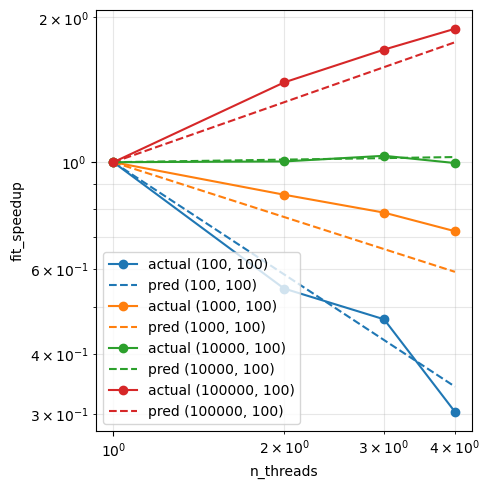

In [3]:
# n_features = 100
plot_fit_speedup_vs_threads(df, model, X_shapes=[(n, 100) for n in [100, 1000, 10_000, 100_000]])

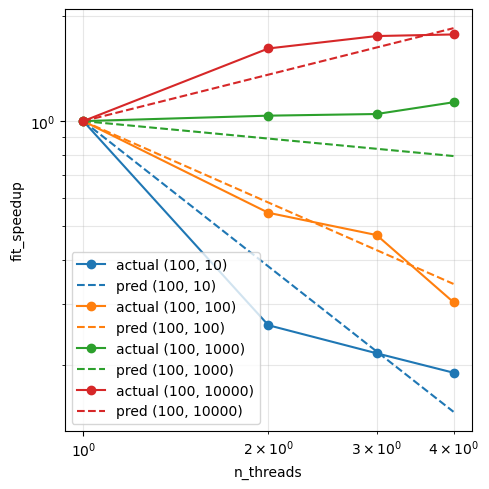

In [4]:
# n_samples = 100
plot_fit_speedup_vs_threads(df, model, X_shapes=[(100, p) for p in [10, 100, 1000, 10_000]])

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

def scatter_actual_vs_pred(df, model, color_by):
    X = df[["n_samples", "n_features", "n_threads"]]
    y_true = df["fit_speedup"].to_numpy()
    y_pred = 10**(model.predict(X))

    plt.figure(figsize=(4.8, 4.8))
    c = df[color_by].to_numpy(dtype=float)
    if np.any(c <= 0):
        raise ValueError(f"{color_by} must be > 0 for log color scale")
    sc = plt.scatter(
        y_true,
        y_pred,
        c=c,
        cmap="viridis",
        s=20,
        alpha=0.7,
        norm=LogNorm(),
    )
    plt.colorbar(sc, label=color_by)

    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    plt.plot([lo, hi], [lo, hi], "k--", lw=1)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("actual fit_speedup")
    plt.ylabel("predicted fit_speedup")
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()


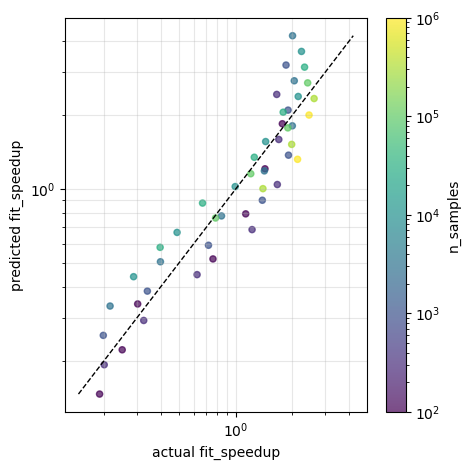

In [6]:
# n_threads=4
scatter_actual_vs_pred(df.query("n_threads==4"), model, color_by="n_samples")

## Checking the heuristics for the predicted best n_threads

The log-linear model `log(fit_speedup) = slope log(n_threads)` with `slope = a*log(n-samples) + b*log(n_features) + c`, which is fitted in the region `1 <= n_threads <= 4`, predicts the optimal number of threads as n_threads=1 if slope <0 and n_threads=4 if slope > 0.

In [7]:
import numpy as np
import pandas as pd

def get_predicted_best_n_threads_df(df, model):
    tmp = df[["n_samples", "n_features", "n_threads"]].copy()
    tmp["predicted_fit_speedup"] = 10**(model.predict(tmp[["n_samples", "n_features", "n_threads"]]))

    idx = tmp.groupby(["n_samples", "n_features"])["predicted_fit_speedup"].idxmax()
    out = (
        tmp.loc[idx, ["n_samples", "n_features", "n_threads"]]
        .rename(columns={"n_threads": "best_n_threads"})
        .sort_values(["n_samples", "n_features"])
        .reset_index(drop=True)
    )
    return out

predicted_best_threads = get_predicted_best_n_threads_df(df, model)
display(predicted_best_threads.head())

,n_samples,n_features,best_n_threads
0,100,10,1
1,100,31,1
2,100,100,1
3,100,316,1
4,100,1000,1


In [8]:
def plot_fit_speedup_vs_threads_actual_best(df, predicted_best_threads, X_shapes):
    merged = df.merge(predicted_best_threads, on=["n_samples", "n_features"])
    at_best = merged[merged["n_threads"] == merged["best_n_threads"]].drop(columns=["best_n_threads"])

    plt.figure(figsize=(5, 5))

    for i, (n_samples, n_features) in enumerate(X_shapes):
        sub = df[(df["n_samples"] == n_samples) & (df["n_features"] == n_features)].sort_values("n_threads")
        if len(sub) == 0:
            raise ValueError(f"no rows for n_samples={n_samples}, n_features={n_features}")

        (line_actual,) = plt.plot(
            sub["n_threads"],
            sub["fit_speedup"],
            "o-",
            label=f"actual ({n_samples}, {n_features})",
        )
        color = line_actual.get_color()

        pt = at_best[(at_best["n_samples"] == n_samples) & (at_best["n_features"] == n_features)]
        if len(pt) != 1:
            raise ValueError(f"expected one best row for ({n_samples}, {n_features}), got {len(pt)}")
        plt.scatter(
            pt["n_threads"],
            pt["fit_speedup"],
            s=140,
            marker="*",
            color=color,
            edgecolors="k",
            linewidths=0.6,
            alpha=0.5,
            zorder=5,
            label="best n_threads" if i == 0 else None,
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("n_threads")
    plt.ylabel("fit_speedup")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()

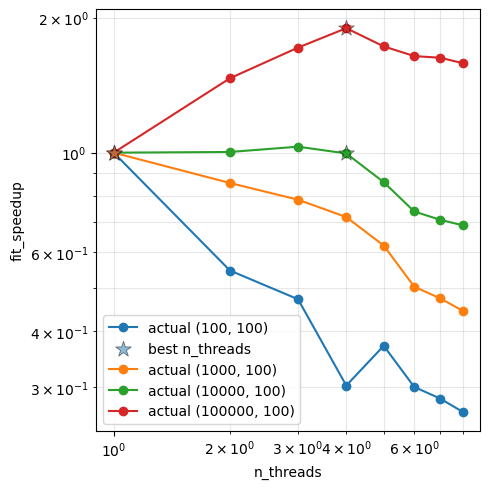

In [9]:
# n_features = 100
plot_fit_speedup_vs_threads_actual_best(
    df_full, predicted_best_threads, X_shapes=[(n, 100) for n in [100, 1000, 10_000, 100_000]]
)

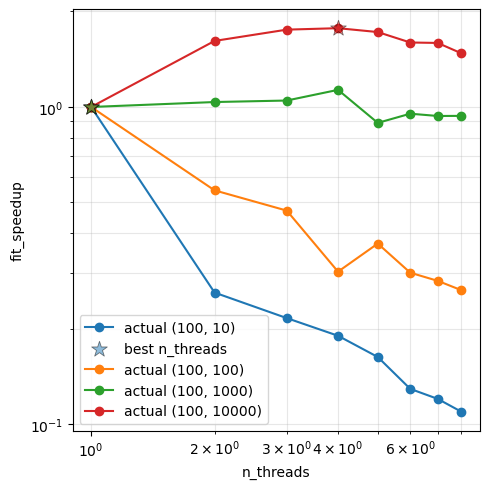

In [10]:
# n_samples = 100
plot_fit_speedup_vs_threads_actual_best(
    df_full, predicted_best_threads, X_shapes=[(100, p) for p in [10, 100, 1000, 10_000]]
)

## Compare actual vs predicted best n_threads

In [11]:
import numpy as np
import pandas as pd

def get_actual_best_n_threads_df(df):
    idx = df.groupby(["n_samples", "n_features"])["fit_speedup"].idxmax()
    return (
        df.loc[idx, ["n_samples", "n_features", "n_threads"]]
        .rename(columns={"n_threads": "best_n_threads"})
        .sort_values(["n_samples", "n_features"])
        .reset_index(drop=True)
    )

actual_best_threads = get_actual_best_n_threads_df(df_full)
compare_best_threads = (
    actual_best_threads.merge(
        predicted_best_threads.rename(columns={"best_n_threads": "predicted_best_n_threads"}),
        on=["n_samples", "n_features"],
    ).rename(columns={"best_n_threads": "actual_best_n_threads"})
)
display(compare_best_threads.head())

,n_samples,n_features,actual_best_n_threads,predicted_best_n_threads
0,100,10,1,1
1,100,31,1,1
2,100,100,1,1
3,100,316,1,1
4,100,1000,4,1


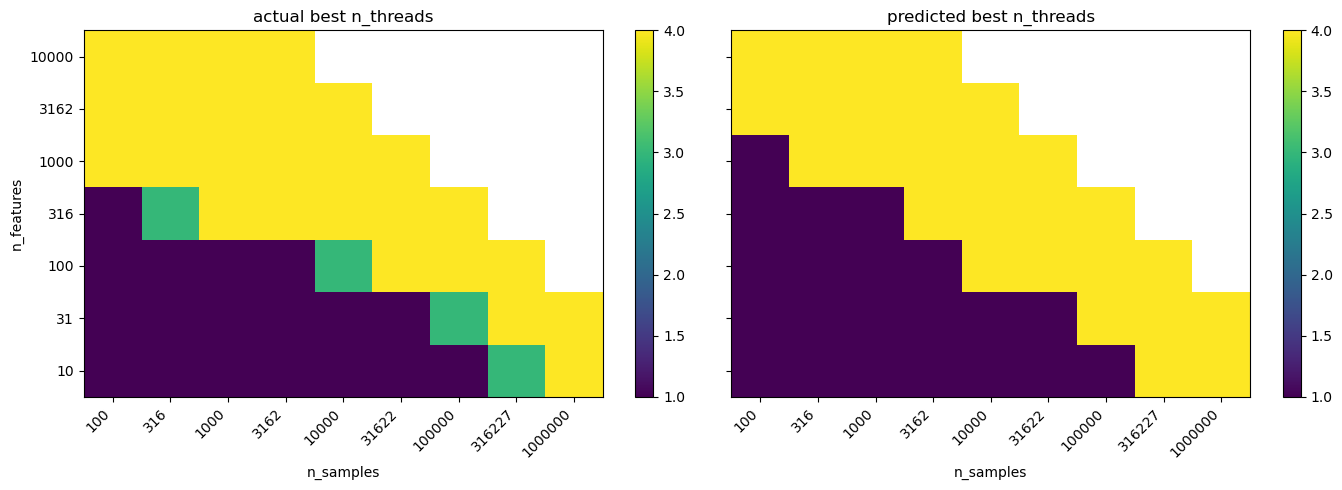

In [12]:
import matplotlib.pyplot as plt


def plot_best_n_threads_heatmaps(compare_best_threads):
    samples = sorted(compare_best_threads["n_samples"].unique())
    feats = sorted(compare_best_threads["n_features"].unique())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, col, title in zip(
        axes,
        ["actual_best_n_threads", "predicted_best_n_threads"],
        ["actual best n_threads", "predicted best n_threads"],
    ):
        pivot = (
            compare_best_threads.pivot(index="n_features", columns="n_samples", values=col)
            .reindex(index=feats, columns=samples)
        )
        im = ax.imshow(pivot.values, origin="lower", aspect="auto", vmin=1, vmax=4, interpolation="nearest")
        fig.colorbar(im, ax=ax)
        ax.set_xlabel("n_samples")
        ax.set_title(title)
        ax.set_xticks(range(len(samples)))
        ax.set_xticklabels(samples, rotation=45, ha="right")
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats)
    axes[0].set_ylabel("n_features")
    fig.tight_layout()


plot_best_n_threads_heatmaps(compare_best_threads)


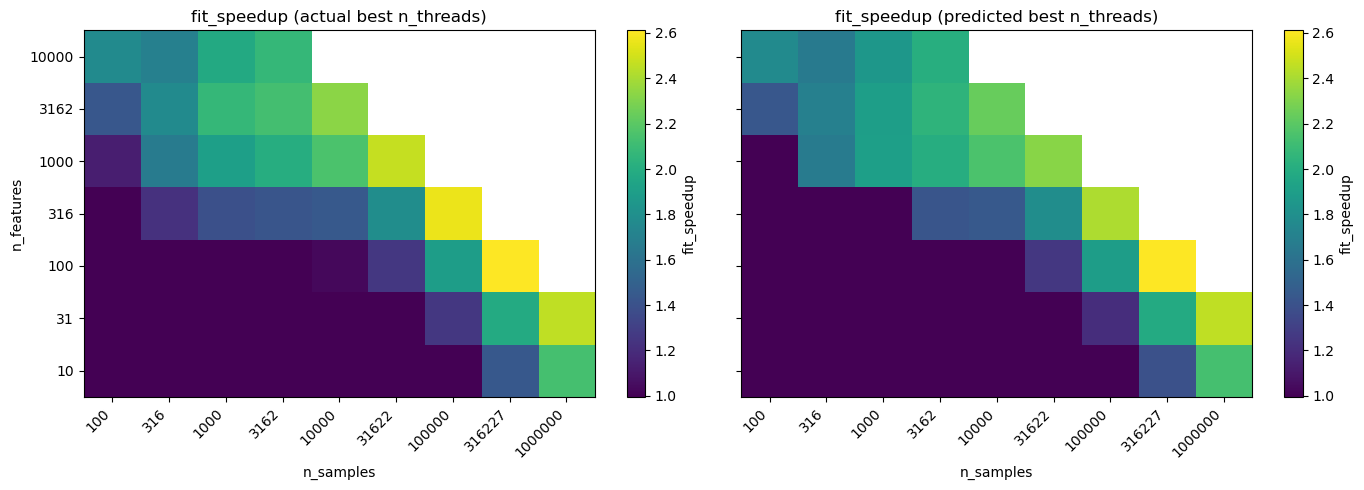

In [13]:
def plot_fit_speedup_heatmaps_at_best(compare_best_threads, df):
    samples = sorted(compare_best_threads["n_samples"].unique())
    feats = sorted(compare_best_threads["n_features"].unique())

    def pivot_speedup(thread_col):
        m = compare_best_threads[["n_samples", "n_features", thread_col]].merge(
            df,
            left_on=["n_samples", "n_features", thread_col],
            right_on=["n_samples", "n_features", "n_threads"],
            how="inner",
        )
        return m.pivot(index="n_features", columns="n_samples", values="fit_speedup").reindex(
            index=feats, columns=samples
        )

    actual_pivot = pivot_speedup("actual_best_n_threads")
    pred_pivot = pivot_speedup("predicted_best_n_threads")
    vmin = np.nanmin(np.r_[actual_pivot.values.ravel(), pred_pivot.values.ravel()])
    vmax = np.nanmax(np.r_[actual_pivot.values.ravel(), pred_pivot.values.ravel()])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, pivot, title in zip(
        axes,
        [actual_pivot, pred_pivot],
        ["fit_speedup (actual best n_threads)", "fit_speedup (predicted best n_threads)"],
    ):
        im = ax.imshow(
            pivot.values,
            origin="lower",
            aspect="auto",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        fig.colorbar(im, ax=ax, label="fit_speedup")
        ax.set_xlabel("n_samples")
        ax.set_title(title)
        ax.set_xticks(range(len(samples)))
        ax.set_xticklabels(samples, rotation=45, ha="right")
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats)
    axes[0].set_ylabel("n_features")
    fig.tight_layout()


plot_fit_speedup_heatmaps_at_best(compare_best_threads, df_full)

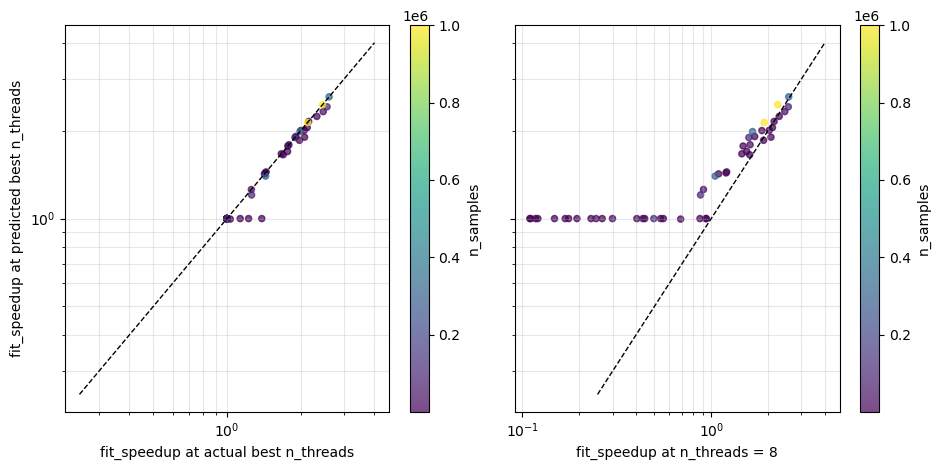

In [14]:
def scatter_fit_speedup_at_best(compare_best_threads, df, color_by="n_samples", n_threads_ref=8):
    d = df[["n_samples", "n_features", "n_threads", "fit_speedup"]].drop_duplicates(
        ["n_samples", "n_features", "n_threads"]
    )
    base = compare_best_threads[
        ["n_samples", "n_features", "actual_best_n_threads", "predicted_best_n_threads"]
    ]

    m = base.merge(
        d,
        left_on=["n_samples", "n_features", "actual_best_n_threads"],
        right_on=["n_samples", "n_features", "n_threads"],
        how="inner",
    ).drop(columns=["n_threads"])
    m = m.rename(columns={"fit_speedup": "fit_speedup_actual"})

    m = m.merge(
        d.rename(columns={"fit_speedup": "fit_speedup_pred"}),
        left_on=["n_samples", "n_features", "predicted_best_n_threads"],
        right_on=["n_samples", "n_features", "n_threads"],
        how="inner",
    ).drop(columns=["n_threads"])

    t8 = d[d["n_threads"] == n_threads_ref][["n_samples", "n_features", "fit_speedup"]].rename(
        columns={"fit_speedup": "fit_speedup_t8"}
    )
    m = m.merge(t8, on=["n_samples", "n_features"], how="inner")

    fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.8), sharey=True)

    sc0 = axes[0].scatter(
        m["fit_speedup_actual"],
        m["fit_speedup_pred"],
        c=m[color_by],
        cmap="viridis",
        s=20,
        alpha=0.7,
    )
    fig.colorbar(sc0, ax=axes[0], label=color_by)

    lo = 1 / 4
    hi = 4
    axes[0].plot([lo, hi], [lo, hi], "k--", lw=1)
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("fit_speedup at actual best n_threads")
    axes[0].set_ylabel("fit_speedup at predicted best n_threads")
    axes[0].grid(True, which="both", alpha=0.3)

    sc1 = axes[1].scatter(
        m["fit_speedup_t8"],
        m["fit_speedup_pred"],
        c=m[color_by],
        cmap="viridis",
        s=20,
        alpha=0.7,
    )
    fig.colorbar(sc1, ax=axes[1], label=color_by)
    axes[1].plot([lo, hi], [lo, hi], "k--", lw=1)
    axes[1].set_xscale("log")
    axes[1].set_xlabel(f"fit_speedup at n_threads = {n_threads_ref}")
    axes[1].grid(True, which="both", alpha=0.3)

    fig.tight_layout()


scatter_fit_speedup_at_best(compare_best_threads, df_full, color_by="n_samples")

## Errors

In [15]:
# It's pretty good

# There are 3 real errors where we wrongly predicted single-threaded as the best
wrong_pred = compare_best_threads.query(
    "actual_best_n_threads != predicted_best_n_threads & predicted_best_n_threads==1"
)
display(wrong_pred)

# The are cases where we correctly predicted multi-threaded as the best, but the actual best n_threads is not 4
best_n_thread_is_not_4 = compare_best_threads.query(
    "actual_best_n_threads != 4  & predicted_best_n_threads==4"
).sort_values(by="actual_best_n_threads")
display(best_n_thread_is_not_4)

,n_samples,n_features,actual_best_n_threads,predicted_best_n_threads
4,100,1000,4,1
10,316,316,3,1
17,1000,316,4,1


,n_samples,n_features,actual_best_n_threads,predicted_best_n_threads
30,10000,100,3,4
40,100000,31,3,4
43,316227,10,3,4
12,316,3162,5,4
13,316,10000,6,4
20,1000,10000,6,4
26,3162,3162,7,4
27,3162,10000,7,4
33,10000,3162,7,4
38,31622,1000,7,4


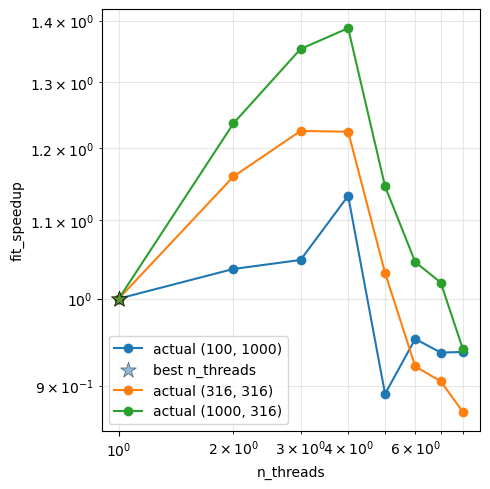

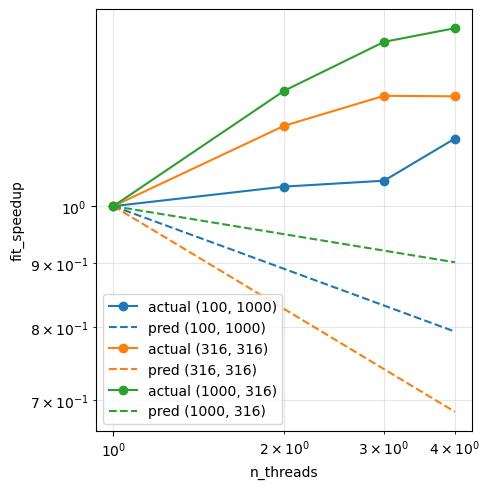

In [16]:
# wrongly predicted single threaded as the best
bad_X_shapes = [
    (int(n), int(p))
    for (n, p) in wrong_pred[["n_samples", "n_features"]].to_numpy()
]
plot_fit_speedup_vs_threads_actual_best(df_full, predicted_best_threads, X_shapes=bad_X_shapes)
# the fit is indeed bad for these 3 shapes
plot_fit_speedup_vs_threads(df, model, X_shapes=bad_X_shapes)

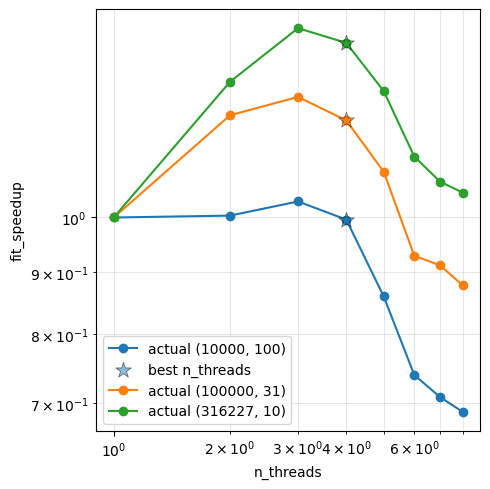

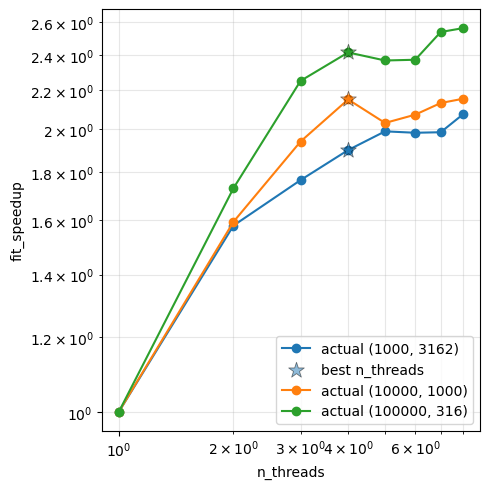

In [17]:
# predicted n_threads=4 as the best, but it's 3
best_n_thread_is_3 = compare_best_threads.query("actual_best_n_threads == 3  & predicted_best_n_threads==4")
bad_X_shapes = [
    (int(n), int(p))
    for (n, p) in best_n_thread_is_3[["n_samples", "n_features"]].to_numpy()
]
plot_fit_speedup_vs_threads_actual_best(df_full, predicted_best_threads, X_shapes=bad_X_shapes)
# predicted n_threads=4 as the best, but it's 8
best_n_thread_is_8 = compare_best_threads.query("actual_best_n_threads == 8  & predicted_best_n_threads==4")
bad_X_shapes = [
    (int(n), int(p))
    for (n, p) in best_n_thread_is_8[["n_samples", "n_features"]].to_numpy()
]
plot_fit_speedup_vs_threads_actual_best(df_full, predicted_best_threads, X_shapes=bad_X_shapes)